# Content Refresh Prioritization Engine


# 1. Predict whether a piece of content is likely to be in the "needs refresh"



In [17]:
import pandas as pd

df = pd.read_csv('content_refresh_anonymized.csv')

# Predict whether a piece of content is likely to be in the "needs refresh"


# drop rows with no value in the 'needs_refresh' column
label_inputs = ["trend_pct", "search_volume", "days_since_last_update"]
df = df.dropna(subset=label_inputs).copy()

df["needs_refresh"] = (
  (df["trend_pct"] <= -20)
    & (df["search_volume"] > 0)
    & (df["days_since_last_update"] >= 30)  
).astype (int)


print(f"Total labeled rows: {len(df)}")
print(f"Positive rate (needs_refresh=1): {df['needs_refresh'].mean():.1%}\n")

Total labeled rows: 25287
Positive rate (needs_refresh=1): 11.5%



![Predict whether a piece of content.png](<attachment:Predict whether a piece of content.png>)
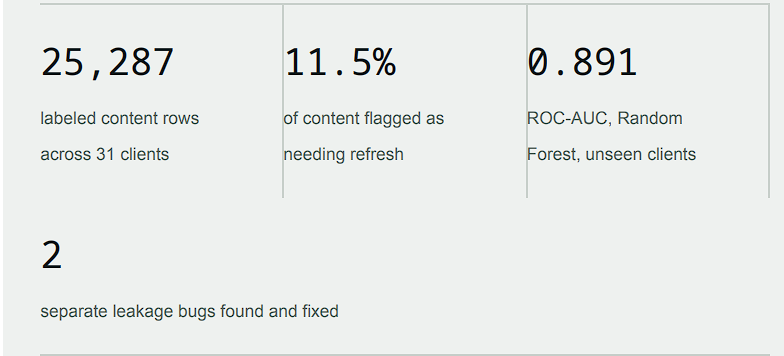

# 2. Feature selection (leakage-safe: "content DNA" only)


In [18]:

NUM_FEATURES = [
    "competition", "cpc", "word_count", "char_count",
    
]
CAT_FEATURES = [
    "competition_level", "content_type", "main_intent", 
    "word_count_tier", "char_count_tier", "provider_used", "model_used",
]
 
X = df[NUM_FEATURES + CAT_FEATURES].copy()
y = df["needs_refresh"]
groups = df["client_id"]  # group by client to avoid leaking a client's pattern into test set
 
for c in CAT_FEATURES:
    X[c] = X[c].fillna("unknown")



## 3. Train / test split (by client_id, NOT random rows)



In [19]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
# GroupShuffleSplit (instead of train_test_split) ensures all rows for a given client_id land

train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {len(X_train)} rows / {groups.iloc[train_idx].nunique()} clients")
print(f"Test:  {len(X_test)} rows / {groups.iloc[test_idx].nunique()} clients\n")






Train: 19707 rows / 23 clients
Test:  5580 rows / 8 clients



## 4. Preprocessing & Model Building

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]),
        NUM_FEATURES,
    ),
    (
        "cat",
        Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value="unknown")),
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]),
        CAT_FEATURES,
    ),
])

models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]),
}

results = {}
for name, model in models.items():
  model.fit(X_train, y_train)
  pred = model.predict(X_test)
  proba = model.predict_proba(X_test)[:, 1]
  auc = roc_auc_score(y_test, proba)
  results[name] = model

  print(f"=== {name} ===")
  print(classification_report(y_test, pred, digits=3))
  print("ROC-AUC:", round(auc, 3))
  print("Confusion Matrix [[TN, FP], [FN, TP]]:")
  print(confusion_matrix(y_test, pred))
  print("\n" + "-" * 50 + "\n")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0      0.955     0.977     0.966      5217
           1      0.502     0.336     0.403       363

    accuracy                          0.935      5580
   macro avg      0.728     0.656     0.684      5580
weighted avg      0.925     0.935     0.929      5580

ROC-AUC: 0.879
Confusion Matrix [[TN, FP], [FN, TP]]:
[[5096  121]
 [ 241  122]]

--------------------------------------------------

=== Random Forest ===
              precision    recall  f1-score   support

           0      0.960     0.959     0.959      5217
           1      0.419     0.427     0.423       363

    accuracy                          0.924      5580
   macro avg      0.689     0.693     0.691      5580
weighted avg      0.925     0.924     0.925      5580

ROC-AUC: 0.891
Confusion Matrix [[TN, FP], [FN, TP]]:
[[5002  215]
 [ 208  155]]

--------------------------------------------------



![Preprocessing & Model Building.png](<attachment:Preprocessing & Model Building.png>)
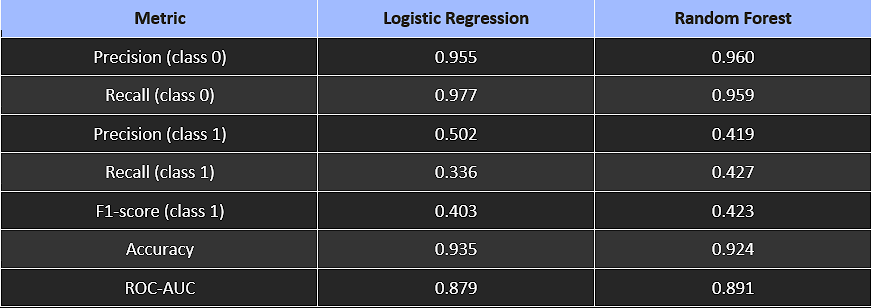

## 5. Feature Importance Analysis (Random Forest)



In [21]:
rf_model = results["Random Forest"]

# One-Hot Encoding
ohe = (
    rf_model.named_steps["prep"]
    .named_transformers_["cat"]
    .named_steps["ohe"]
)
feature_names = NUM_FEATURES + list(ohe.get_feature_names_out(CAT_FEATURES))
importances = rf_model.named_steps["clf"].feature_importances_

imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
)

print("=== Top 15 Most Important Features (Random Forest) ===")
print(imp_df.to_string(index=False))

=== Top 15 Most Important Features (Random Forest) ===
                          feature  importance
                      competition    0.129481
                       word_count    0.116681
                       char_count    0.114873
        main_intent_informational    0.088218
        word_count_tier_1000-2000    0.075530
      char_count_tier_15000-25000    0.068409
        word_count_tier_2000-3500    0.058160
           model_used_gpt-4o-mini    0.045360
model_used_gemini-3-flash-preview    0.035850
        main_intent_transactional    0.035562
       char_count_tier_8000-15000    0.033654
                              cpc    0.033120
            provider_used_unknown    0.026396
           main_intent_commercial    0.020665
             provider_used_google    0.019337


![Feature Importance Analysis.png](<attachment:Feature Importance Analysis.png>)
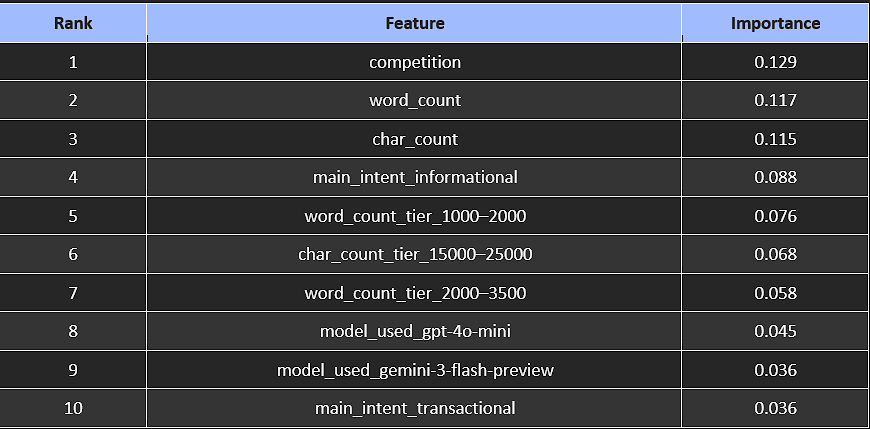
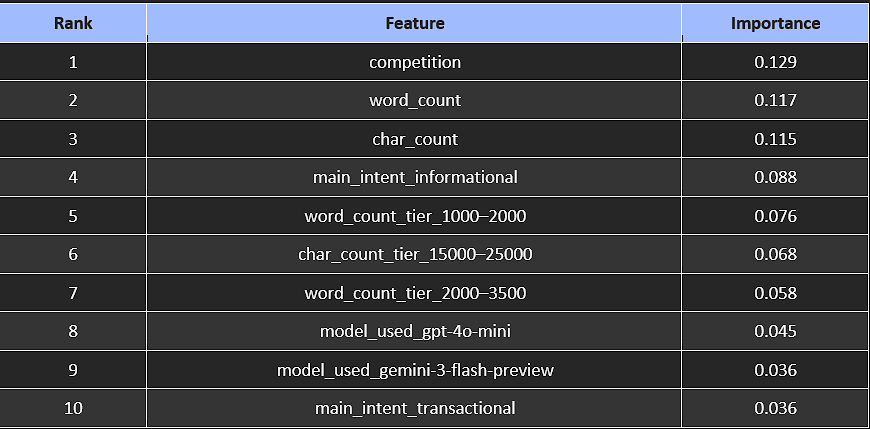

# 6. Prioritization Score Mapping

In [22]:
from sklearn.model_selection import GroupKFold, cross_val_predict

n_splits = min(5, groups.nunique())
gkf = GroupKFold(n_splits=n_splits)
oof_proba = cross_val_predict(
    results["Random Forest"], X, y, groups=groups, cv=gkf, method="predict_proba", n_jobs=-1
)[:, 1]

df["refresh_priority_score"] = oof_proba

top_priority = df.sort_values("refresh_priority_score", ascending=False)[
    [
        "content_id",
        "client_id",
        "refresh_priority_score",
        "needs_refresh",
        "trend_pct",
        "search_volume",
        "content_age_days",
    ]
].head(20)

print("\n=== Top 20 Highest-Priority Content Pieces ===")
print(top_priority.to_string(index=False))



=== Top 20 Highest-Priority Content Pieces ===
          content_id         client_id  refresh_priority_score  needs_refresh  trend_pct  search_volume  content_age_days
content_ca8a4b9161eb client_4e07408562                0.969447              0       24.2          140.0               326
content_6596b1355bab client_4e07408562                0.967753              1      -22.3          110.0               326
content_278982959883 client_8527a891e2                0.967491              0       36.8          590.0               272
content_87845043b009 client_8527a891e2                0.967191              1     -100.0           10.0               238
content_dbb4c75afccc client_4e07408562                0.967047              0       51.2           10.0               300
content_6ab7fd4c71af client_4e07408562                0.966634              1      -27.1           10.0               348
content_c22f0bebb1d1 client_4e07408562                0.965965              0       24.6          